### Nome: Wesley Vitorino Teixeira
### Matrícula: 2260602

## Import all packages need in the cell below

In [7]:
# Todos os imports

using ForwardDiff
using LinearAlgebra
using JuMP
using GLPK

### Task 1.1

Consider the following function

$$f(x_1, x_2, x_3) = x_3 \log\left(e^{\frac{x_1}{x_3}} + e^{\frac{x_2}{x_3}}\right) + (x_3 - 2)^2 + e^{\frac{1}{x_1 + x_2}}$$

Where the function $f : \mathbb{R}^3 \to \mathbb{R}$ has its domain as

$$\text{dom} f = \{ x \in \mathbb{R}^3 : x_1 + x_2 > 0, x_3 > 0 \}.$$

**(a)** Implement different numerical methods in Julia to optimize the given convex function

i. Gradient descent with backtracking line search. Use $t_{\text{init}} = 1$, $\alpha = 0.4$, $\beta = \frac{1}{2}$

ii. Newton's method (use same values for line search as part i)

**Hints:**

1. You can either calculate the gradient/Hessian analytically or use the finite difference method, i.e., $f'(x) = \frac{f(x+h) - f(x)}{h}$ where $h$ is a small number like $10^{-5}$.

2. Be cautious of the domain while implementing the numerical methods.

Take tolerance of $10^{-5}$ for the gradient norm wherever necessary.

In [ ]:
# 1. Define the objective function
function f(x)
    x1, x2, x3 = x[1], x[2], x[3]
    
    # Domain check: x1 + x2 > 0 and x3 > 0
    if x1 + x2 <= 0 || x3 <= 0
        return Inf
    end
    
    term1 = x3 * log(exp(x1/x3) + exp(x2/x3))
    term2 = (x3 - 2)^2
    term3 = exp(1 / (x1 + x2))
    
    return term1 + term2 + term3
end

# 2. Backtracking Line Search Helper
function backtracking_line_search(f, x, grad, Δx; t_init=1.0, α=0.4, β=0.5)
    t = t_init
    # Ensure initial step doesn't land outside domain
    while f(x + t * Δx) == Inf || f(x + t * Δx) > f(x) + α * t * dot(grad, Δx)
        t *= β
        if t < 1e-12 break end # Safety break
    end
    return t
end

# 3. Gradient Descent
function gradient_descent(f, x0; tol=1e-5, max_iter=1000)
    x = copy(x0)
    println("Starting Gradient Descent...")
    for i in 1:max_iter
        grad = ForwardDiff.gradient(f, x)
        if norm(grad) < tol
            println("Converged in $i iterations.")
            return x, f(x)
        end
        
        Δx = -grad
        t = backtracking_line_search(f, x, grad, Δx)
        x += t * Δx
    end
    return x, f(x)
end

# 4. Newton's Method
function newton_method(f, x0; tol=1e-5, max_iter=100)
    x = copy(x0)
    println("\nStarting Newton's Method...")
    for i in 1:max_iter
        grad = ForwardDiff.gradient(f, x)
        hess = ForwardDiff.hessian(f, x)
        
        if norm(grad) < tol
            println("Converged in $i iterations.")
            return x, f(x)
        end
        
        # Newton direction: Δx = -H⁻¹ * g
        Δx = -hess \ grad
        
        # Backtracking line search
        t = backtracking_line_search(f, x, grad, Δx)
        x += t * Δx
    end
    return x, f(x)
end

# --- Execution ---
# Initial point must be within domain (x1+x2 > 0, x3 > 0)
x_start = [1.0, 1.0, 1.0]

x_opt_gd, f_opt_gd = gradient_descent(f, x_start)
println("GD Optimal x: $x_opt_gd, f(x): $f_opt_gd")

x_opt_nt, f_opt_nt = newton_method(f, x_start)
println("Newton Optimal x: $x_opt_nt, f(x): $f_opt_nt")

Starting Gradient Descent...
Converged in 10 iterations.
GD Optimal x: [0.9262118966884297, 0.9262118966884297, 1.6534264097200273], f(x): 3.908113786278069

Starting Newton's Method...
Converged in 4 iterations.
Newton Optimal x: [0.926208318725359, 0.926208318725359, 1.6534264097200275], f(x): 3.908113786261894


### Task 1.2
### Optimize the Problem 1 in Julia using one of the Quasi-Newton methods, namely BFGS (Broyden-Fletcher-Goldfarb-Shanno) method.

The below tutorial attempts to aid in understanding the method,

### Quasi-Newton Methods:
For the unconstrained, smooth convex optimization $\min_x f(x)$, where $f$ is convex, twice differentiable, and domain = dom $f$. Earlier we had seen:

**Gradient-Descent Algorithm**
$$x^+ = x - t \nabla f(x)$$

**Newton's Method**
$$x^+ = x - t [\nabla^2 f(x)]^{-1} \nabla f(x)$$
or
$$x^+ = x - t s$$

Where two main steps are to:
- Compute Hessian $\nabla^2 f(x)$
- Solve the system $\nabla^2 f(x) s = -\nabla f(x)$

Now, **Quasi-Newton**
$$x^+ = x - t s$$

Where the direction $s$ is defined by the linear system
$$B s = -\nabla f(x)$$
for some approximation $B$ of $\nabla^2 f(x)$

With the information so far, we now state a Quasi-Newton template:

Let $x^{(0)} \in \text{dom } f$, $B^{(0)} \succ 0$. For $k = 1,2,3,\dots$, repeat:

1. Solve $B^{(k-1)} s^{(k-1)} = -\nabla f(x^{(k-1)})$
2. Update $x^{(k)} = x^{(k-1)} + t_k s^{(k-1)}$
3. Compute $B^{(k)}$ from $B^{(k-1)}$

### Final Note on Implementation:

- During the practical implementation of the algorithm in a compiler, the numerical value of $y_k^T s_k$ can get very small (since $y_k$ involves difference of $\nabla f$) which can lead to error of $1/0$ form while calculating $\rho_k$. Thus, it can be a good idea to set $\rho_k$ as a constant after $y_k^T s_k$ gets smaller than some certain $\varepsilon$ say $10^{-5}$.

- Take initial $H_0 = I$ (Identity matrix)

For more information, refer:
*Numerical Optimization* (Jorge Nocedal and Stephen J. Wright), Springer, 2006. (Chapter 6)

In [3]:
# 1. Define the objective function (f: R^3 -> R)
function f(x)
    x1, x2, x3 = x[1], x[2], x[3]
    
    # Domain constraints
    if x1 + x2 <= 0 || x3 <= 0
        return Inf
    end
    
    term1 = x3 * log(exp(x1/x3) + exp(x2/x3))
    term2 = (x3 - 2)^2
    term3 = exp(1 / (x1 + x2))
    
    return term1 + term2 + term3
end

# 2. Backtracking Line Search (Armijo Condition)
function backtracking_line_search(f, x, grad, p; t_init=1.0, α=0.4, β=0.5)
    t = t_init
    # Ensure next point is in domain and satisfies descent condition
    while f(x + t * p) == Inf || f(x + t * p) > f(x) + α * t * dot(grad, p)
        t *= β
        if t < 1e-12 break end
    end
    return t
end

# 3. BFGS Quasi-Newton Method
function bfgs_optimize(f, x0; tol=1e-5, max_iter=200)
    n = length(x0)
    x = copy(x0)
    H = Matrix{Float64}(I, n, n) # Initial Inverse Hessian approximation (Identity)
    
    println("Starting BFGS Optimization...")
    
    for k in 1:max_iter
        grad = ForwardDiff.gradient(f, x)
        
        # Check convergence
        if norm(grad) < tol
            println("Converged in $k iterations.")
            return x, f(x)
        end
        
        # Search direction p = -H * grad
        p = -H * grad
        
        # Step size via backtracking
        t = backtracking_line_search(f, x, grad, p)
        
        # Update variables
        x_next = x + t * p
        grad_next = ForwardDiff.gradient(f, x_next)
        
        s = x_next - x
        y = grad_next - grad
        
        # Calculate rho with stability check (y's > epsilon)
        ys = dot(y, s)
        if ys > 1e-10
            rho = 1.0 / ys
        else
            rho = 1000.0 # Constant approximation if ys is too small
        end
        
        # BFGS Update for Inverse Hessian H
        I_mat = Matrix{Float64}(I, n, n)
        H = (I_mat - rho * s * y') * H * (I_mat - rho * y * s') + rho * s * s'
        
        x = x_next
    end
    
    return x, f(x)
end

# --- Execution ---
x_start = [1.5, 1.5, 1.5] # Starting point within domain
x_opt, f_opt = bfgs_optimize(f, x_start)

println("-"^30)
println("Optimal Solution: ", x_opt)
println("Minimum Value:    ", f_opt)
println("-"^30)

Starting BFGS Optimization...
Converged in 8 iterations.
------------------------------
Optimal Solution: [0.9262080145523234, 0.9262080145523234, 1.6534266883790378]
Minimum Value:    3.9081137862622155
------------------------------


### Task 1.3

Consider a well-stirred chemical reactor depicted in Figure 5, where an irreversible, first-order reaction $A \rightarrow B$ occurs in the liquid phase. The feed to the reactor consists of pure A at flowrate $F_0$, temperature $T_0$, and molar concentration $c_0$. Note that the reactor temperature can be regulated with external cooling with temperature $T_c$.

Based on first principles, the following nonlinear state space model can be obtained which involves the mass and energy balances:

$$
\begin{aligned}
\frac{dc}{dt} &= \frac{F_0}{\pi r^2}(c_0 - c) - k_0 \exp\left(-\frac{E}{RT}\right)c \\
\frac{dT}{dt} &= \frac{F_0}{\pi r^2}(T_0 - T) - \frac{\Delta H}{\rho c_p} k_0 \exp\left(-\frac{E}{RT}\right)c + \frac{2U}{r\rho c_p}(T_c - T) \\
\frac{dh}{dt} &= \frac{F_0 - F}{\pi r^2}
\end{aligned}
$$

The controlled variables are the level of the tank, $h$, and the molar concentration of species A, denoted as $c$; the additional state variable is the reactor temperature, denoted as $T$. While, the manipulated variables are the coolant liquid temperature, $T_c$, and the outlet flowrate, $F$.

The open-loop stable steady-state operating conditions can be obtained with specified model parameters and are the following:

$$
\begin{aligned}
c_s &= 0.878 \text{ kmol/m}^3 \\
T_s^c &= 300 \text{ K} \\
T_s &= 324.5 \text{ K} \\
h_s &= 0.659 \text{ m} \\
F_s &= 0.1 \text{ m}^3/\text{min}
\end{aligned}
$$

Using a sampling time of 1 min, a linearized discrete state space model is obtained to approximate the complex process model (i.e., the set of ODE equations). It is also assumed that all the states are measurable without noise. Shifted by the given steady state, the state space variables are

$$
\mathbf{x} = \begin{bmatrix} c - c_s \\ T - T_s \\ h - h_s \end{bmatrix}, \quad \mathbf{u} = \begin{bmatrix} T_c - T_s^c \\ F - F_s \end{bmatrix}
$$

The corresponding linear model is

$$
\begin{aligned}
\mathbf{x}(k+1) &= \mathbf{A} \mathbf{x}(k) + \mathbf{B} \mathbf{u}(k) \\
\mathbf{y}(k) &= \mathbf{C} \mathbf{x}(k)
\end{aligned}
$$

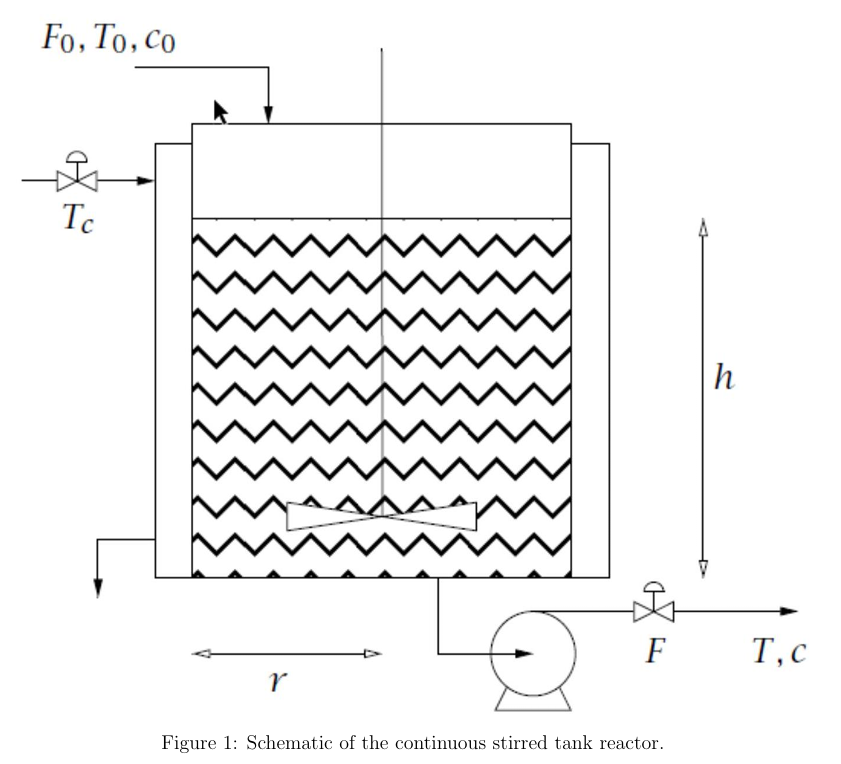


**Figure 1:** Schematic of the continuous stirred tank reactor.

$$
\mathbf{A} = \begin{bmatrix}
0.2681 & -0.00338 & -0.00728 \\
9.703 & 0.3279 & -25.44 \\
0 & 0 & 1
\end{bmatrix}, \quad
\mathbf{B} = \begin{bmatrix}
-0.00537 & 0.1655 \\
1.297 & 97.91 \\
0 & -6.637
\end{bmatrix}, \quad
\mathbf{C} = \begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

The goal in this case is to develop an optimization problem to drive the two controlled variables, $c$ and $h$, from the given initial value to the specified constant setpoints. Specifically, the considered time instants are from 0 to 3 (i.e., $k = 0, 1, 2, 3$), and the initial states and the setpoints for the two controlled variables are given as

$$
\mathbf{x}(k=0) = \begin{bmatrix} -0.03 \\ 0 \\ 0.3 \end{bmatrix}, \quad c_{sp} = 0, \quad h_{sp} = 0
$$

In this sense, the objective function is to minimize the deviation of the two controlled variables from their setpoints over the time horizon, which can be derived as follows

$$
\min \sum_k \left( |y_1(k) - c_{sp}| + |y_3(k) - h_{sp}| \right)
$$

Also, the bounds for the input and state variables are given as follows

$$
\begin{bmatrix} -0.05 \\ -5 \\ -0.5 \end{bmatrix} \leq \mathbf{x}(k) \leq \begin{bmatrix} 0.05 \\ 5 \\ 0.5 \end{bmatrix}
$$

$$
-10 \leq u_1(k) \leq 10, \quad -0.05 \leq u_2(k) \leq 0.05
$$

Derive the LP problem for this purpose with the given information of the state space model, time horizon, initial state, setpoints, and bounds. Then, use Julia/JuMP to solve the problem.

In [6]:
# 1. Model Parameters
A = [0.2681  -0.00338  -0.00728;
     9.703    0.3279   -25.44;
     0        0         1.0]

B = [-0.00537   0.1655;
      1.297    97.91;
      0       -6.637]

x0 = [-0.03, 0.0, 0.3]
x_min = [-0.05, -5.0, -0.5]
x_max = [ 0.05,  5.0,  0.5]
u_min = [-10.0, -0.05]
u_max = [ 10.0,  0.05]

K = 3 # Time horizon

# 2. Define the Optimization Problem
model = Model(GLPK.Optimizer)

@variables(model, begin
    x_min[i] <= x[i=1:3, k=0:K] <= x_max[i]  # States
    u_min[j] <= u[j=1:2, k=0:K-1] <= u_max[j] # Inputs
    z1[k=1:K] >= 0                            # Slack for |x1|
    z3[k=1:K] >= 0                            # Slack for |x3|
end)

# 3. Objective: Minimize absolute deviation from setpoints (0)
@objective(model, Min, sum(z1[k] + z3[k] for k in 1:K))

# 4. Constraints
# Initial State
for i in 1:3
    @constraint(model, x[i, 0] == x0[i])
end

# Dynamics and Slack Linearization
for k in 0:K-1
    # x(k+1) = Ax(k) + Bu(k)
    @constraint(model, x[:, k+1] .== A * x[:, k] + B * u[:, k])
    
    # Absolute value linearization for k+1
    @constraint(model, x[1, k+1] <= z1[k+1])
    @constraint(model, -x[1, k+1] <= z1[k+1])
    @constraint(model, x[3, k+1] <= z3[k+1])
    @constraint(model, -x[3, k+1] <= z3[k+1])
end

# 5. Solve
optimize!(model)

# 6. Display Results
if termination_status(model) == MOI.OPTIMAL
    println("Optimal Solution Found!")
    for k in 0:K
        println("k=$k: x=$(value.(x[:, k]))")
        if k < K
            println("     u=$(value.(u[:, k]))")
        end
    end
    println("Total Objective Value: ", objective_value(model))
else
    println("Problem could not be solved.")
end

Optimal Solution Found!
k=0: x=1-dimensional DenseAxisArray{Float64,1,...} with index sets:
    Dimension 1, Base.OneTo(3)
And data, a 3-element Vector{Float64}:
 -0.03
  0.0
  0.30000000000000016
     u=1-dimensional DenseAxisArray{Float64,1,...} with index sets:
    Dimension 1, Base.OneTo(2)
And data, a 2-element Vector{Float64}:
 -0.5113986008688389
  0.0452011450956758
k=1: x=1-dimensional DenseAxisArray{Float64,1,...} with index sets:
    Dimension 1, Base.OneTo(3)
And data, a 3-element Vector{Float64}:
 -6.938893903907228e-18
 -4.160729869009268
 -1.1102230246251565e-16
     u=1-dimensional DenseAxisArray{Float64,1,...} with index sets:
    Dimension 1, Base.OneTo(2)
And data, a 2-element Vector{Float64}:
  2.618857906378274
 -1.3877787807814457e-16
k=2: x=1-dimensional DenseAxisArray{Float64,1,...} with index sets:
    Dimension 1, Base.OneTo(3)
And data, a 3-element Vector{Float64}:
 -5.551115123125783e-17
  2.032355380524474
  6.661338147750939e-16
     u=1-dimensional DenseA